
# MMRL / MMRLMix 分支相似性与互补性分析（完整可运行版）

这个 notebook 的目标是**直接基于训练好的 checkpoint 重新推理**，分析：

- 主分支 `z_c`
- rep 分支 `z_r`
- fusion 分支 `z_f = alpha * z_c + (1-alpha) * z_r`

以及更底层的图像特征：

- 主分支图像特征 `f_c`
- rep 分支图像特征 `f_r`

你可以用它验证下面这些问题：

1. `z_c` 和 `z_r` 是否越来越相似
2. 两条分支是否失去互补性
3. fusion 是在纠错，还是在把较优分支拉坏
4. `f_c` 和 `f_r` 的特征相似度是否上升

---

## 运行前提

你需要：

1. 已经有训练好的 case 目录，例如  
   `output_refactor/MMRL/FS/fewshot_train/caltech101/shots_8/ViT-B-16/default/seed1`
2. 本 notebook 在 **仓库根目录外** 也能运行，但你需要正确填写 `REPO_ROOT`
3. `REPO_ROOT` 下应包含 `MMRL/run.py`、`MMRL/core/config.py`、`MMRL/trainers/refactor_runner.py` 等代码和 `DATASETS`

---

## 你需要改的只有一个地方

下面的 **配置单元** 里：

- `REPO_ROOT`
- `DATA_ROOT`
- `CASES`

其中 `CASES` 可以放任意多个实验，用来比较：
- MMRL vs MMRLMix
- 不同 shot
- 不同 seed
- 不同 loss 版本


In [ ]:

from pathlib import Path

# ====== 这里改成你本地仓库路径 ======
REPO_ROOT = Path("/root/autodl-tmp/MMRL/").expanduser().resolve()

# 如果 DATASETS 不在 REPO_ROOT 下，改成实际路径
DATA_ROOT = REPO_ROOT / "DATASETS"

# 你要对比的实验。可以随便加。
# case_root 指向 output_refactor/.../seedX 这一层目录
CASES = [
    {
        "name": "MMRL_16shot_seed1",
        "case_root": REPO_ROOT / "output_refactor/MMRL/FS/fewshot_train/caltech101/shots_16/ViT-B-16/default/seed1",
    },
    {
        "name": "MMRLMix_16shot_seed1",
        "case_root": REPO_ROOT / "output_refactor/MMRLMix/FS/fewshot_train/caltech101/shots_16/ViT-B-16/default/seed1",
    },

]

# 设成整数可以只跑前几个 batch，方便快速调试；正式分析用 None
MAX_BATCHES = None

# 如果你只想分析 test split，就保留 "test"
SPLIT = "test"

assert REPO_ROOT.exists(), f"REPO_ROOT 不存在: {REPO_ROOT}"
assert DATA_ROOT.exists(), f"DATA_ROOT 不存在: {DATA_ROOT}"
for case in CASES:
    assert Path(case["case_root"]).exists(), f'case_root 不存在: {case["case_root"]}'

print("REPO_ROOT =", REPO_ROOT)
print("DATA_ROOT =", DATA_ROOT)
print("CASES =", len(CASES))


REPO_ROOT = /root/autodl-tmp/MMRL
DATA_ROOT = /root/autodl-tmp/MMRL/DATASETS
CASES = 3


In [48]:

import os
import sys
import math
import importlib
from types import SimpleNamespace

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# 让 notebook 能 import 仓库代码
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

# 仓库入口需要在 MMRL 根目录下 import
os.chdir(REPO_ROOT)

from core.config import setup_cfg
from dassl.engine import build_trainer
from core.utils import import_optional_modules

# 与 run.py 对齐的注册逻辑
import_optional_modules([
    'datasets.oxford_pets', 'datasets.oxford_flowers', 'datasets.fgvc_aircraft',
    'datasets.dtd', 'datasets.eurosat', 'datasets.stanford_cars', 'datasets.food101',
    'datasets.sun397', 'datasets.caltech101', 'datasets.ucf101', 'datasets.imagenet',
    'datasets.imagenetv2', 'datasets.imagenet_sketch', 'datasets.imagenet_a', 'datasets.imagenet_r',
])
importlib.import_module('trainers.refactor_runner')

print("torch =", torch.__version__)
print("cuda available =", torch.cuda.is_available())


torch = 2.4.0+cu121
cuda available = True


In [49]:

METHOD_CFG_MAP = {
    "MMRL": "configs/methods/mmrl.yaml",
    "MMRLMix": "configs/methods/mmrl_mix.yaml",
    "MMRLpp": "configs/methods/mmrlpp.yaml",
    "MMRLPP": "configs/methods/mmrlpp.yaml",
    "BayesMMRL": "configs/methods/bayesmmrl.yaml",
    "ClipAdapters": "configs/methods/clip_adapters.yaml",
    "ClipADAPTER": "configs/methods/clip_adapters.yaml",
}

PROTOCOL_CFG_MAP = {
    "B2N": "configs/protocols/b2n.yaml",
    "FS": "configs/protocols/fs.yaml",
    "CD": "configs/protocols/cd.yaml",
}

PROTOCOL_TO_SUBSAMPLE = {
    "B2N": "base",
    "FS": "all",
    "CD": "all",
}

def decode_backbone_from_dir(token: str) -> str:
    """
    output_refactor 目录里把 '/' 变成了 '-'
    例如:
      ViT-B/16 -> ViT-B-16
      ViT-B/32 -> ViT-B-32

    这里要还原回训练时真实使用的 backbone 名称。
    注意不能直接把所有 '-' 都替换成 '/'，
    否则 ViT-B-16 会错误变成 ViT/B/16。
    """
    if token.startswith("ViT-") and token.count("-") >= 2:
        head, patch = token.rsplit("-", 1)
        return f"{head}/{patch}"
    return token


def infer_case_metadata(case_root: Path):
    """
    解析 output_refactor/METHOD/PROTOCOL/phase/dataset/shots_x/backbone/tag/seedx
    """
    case_root = Path(case_root).resolve()
    parts = case_root.parts

    try:
        idx = parts.index("output_refactor")
    except ValueError:
        raise ValueError(f"case_root 中找不到 output_refactor: {case_root}")

    method = parts[idx + 1]
    protocol = parts[idx + 2]
    phase = parts[idx + 3]
    dataset = parts[idx + 4]
    shots_str = parts[idx + 5]

    backbone_token = parts[idx + 6]
    backbone = decode_backbone_from_dir(backbone_token)

    tag = parts[idx + 7]
    seed_dir = parts[idx + 8]

    if not shots_str.startswith("shots_"):
        raise ValueError(f"无法解析 shots: {shots_str}")
    if not seed_dir.startswith("seed"):
        raise ValueError(f"无法解析 seed: {seed_dir}")

    shots = int(shots_str.split("_", 1)[1])
    seed = int(seed_dir.replace("seed", ""))

    return {
        "method": method,
        "protocol": protocol,
        "phase": phase,
        "dataset": dataset,
        "shots": shots,
        "backbone": backbone,
        "tag": tag,
        "seed": seed,
        "case_root": case_root,
    }


def make_args_from_case(meta):
    method = meta["method"]
    protocol = meta["protocol"]
    dataset = meta["dataset"]
    shots = meta["shots"]
    backbone = meta["backbone"]
    seed = meta["seed"]
    case_root = meta["case_root"]

    method_cfg = METHOD_CFG_MAP[method]
    protocol_cfg = PROTOCOL_CFG_MAP[protocol]
    subsample = PROTOCOL_TO_SUBSAMPLE[protocol]

    args = SimpleNamespace(
        root=str(DATA_ROOT),
        output_dir=str(case_root),
        dataset_config_file=f"configs/datasets/{dataset}.yaml",
        method_config_file=method_cfg,
        protocol_config_file=protocol_cfg,
        runtime_config_file="configs/runtime/default.yaml",
        exp_config="",
        method=method,
        protocol=protocol,
        exec_mode="online",
        seed=seed,
        trainer="RefactorRunner",
        eval_only=True,
        model_dir=str(case_root),
        load_epoch=None,
        no_train=True,
        opts=[
            "DATASET.NUM_SHOTS", str(shots),
            "DATASET.SUBSAMPLE_CLASSES", str(subsample),
            "MODEL.BACKBONE.NAME", str(backbone),
        ],
    )
    return args

def build_trainer_for_case(case_root: Path):
    meta = infer_case_metadata(case_root)
    args = make_args_from_case(meta)
    cfg = setup_cfg(args)
    trainer = build_trainer(cfg)
    trainer.load_model(str(case_root))
    trainer.set_model_mode("eval")
    return trainer, meta


In [50]:

@torch.no_grad()
def forward_with_rep_features(model, image):
    """
    复现 methods/mmrl_family/modules.py 中的 forward，
    但额外返回 image_features_rep，方便分析 f_c / f_r 相似性。
    """
    if model.representation_learner.training:
        raise RuntimeError("分析时模型应在 eval 模式下")

    if model.text_features_for_inference is None:
        rep_text, rep_visual = model.representation_learner()
        model.compound_rep_tokens_text_for_inference = rep_text
        model.compound_rep_tokens_visual_for_inference = rep_visual
        model.text_features_for_inference = model.text_encoder(
            model.prompt_embeddings,
            model.tokenized_prompts,
            model.compound_rep_tokens_text_for_inference,
        )

    compound_rep_tokens_visual = model.compound_rep_tokens_visual_for_inference
    text_features = model.text_features_for_inference

    image_features, image_features_rep = model.image_encoder(
        [image.type(model.dtype), compound_rep_tokens_visual]
    )

    image_features = image_features / image_features.norm(dim=-1, keepdim=True)
    image_features_rep = image_features_rep / image_features_rep.norm(dim=-1, keepdim=True)
    text_features = text_features / text_features.norm(dim=-1, keepdim=True)

    logits = 100.0 * image_features @ text_features.t()
    logits_rep = 100.0 * image_features_rep @ text_features.t()
    logits_fusion = model.alpha * logits + (1.0 - model.alpha) * logits_rep

    return {
        "logits": logits,
        "logits_rep": logits_rep,
        "logits_fusion": logits_fusion,
        "image_features": image_features,
        "image_features_rep": image_features_rep,
        "text_features": text_features,
    }

@torch.no_grad()
def collect_case_dataframe(trainer, meta, split="test", max_batches=None):
    if split == "val" and trainer.val_loader is not None:
        loader = trainer.val_loader
    else:
        loader = trainer.test_loader
        split = "test"

    model = trainer.method.model
    model.eval()
    model.clear_inference_cache()

    rows = []
    n_seen = 0

    for batch_idx, batch in enumerate(loader):
        if (max_batches is not None) and (batch_idx >= max_batches):
            break

        image = batch["img"].to(trainer.device)
        label = batch["label"].to(trainer.device)

        out = forward_with_rep_features(model, image)

        zc = out["logits"]
        zr = out["logits_rep"]
        zf = out["logits_fusion"]

        fc = out["image_features"]
        fr = out["image_features_rep"]

        pc = F.softmax(zc, dim=1)
        pr = F.softmax(zr, dim=1)
        pf = F.softmax(zf, dim=1)

        pred_c = zc.argmax(dim=1)
        pred_r = zr.argmax(dim=1)
        pred_f = zf.argmax(dim=1)

        feat_cos = F.cosine_similarity(fc, fr, dim=1)
        logit_cos = F.cosine_similarity(zc, zr, dim=1)

        kl_c_r = F.kl_div(pc.log(), pr, reduction="none").sum(dim=1)
        kl_r_c = F.kl_div(pr.log(), pc, reduction="none").sum(dim=1)
        js = 0.5 * (
            F.kl_div(pc.log(), 0.5 * (pc + pr), reduction="none").sum(dim=1)
            + F.kl_div(pr.log(), 0.5 * (pc + pr), reduction="none").sum(dim=1)
        )

        top2_c = zc.topk(2, dim=1).values
        top2_r = zr.topk(2, dim=1).values
        top2_f = zf.topk(2, dim=1).values

        margin_c = top2_c[:, 0] - top2_c[:, 1]
        margin_r = top2_r[:, 0] - top2_r[:, 1]
        margin_f = top2_f[:, 0] - top2_f[:, 1]

        conf_c = pc.max(dim=1).values
        conf_r = pr.max(dim=1).values
        conf_f = pf.max(dim=1).values

        for i in range(label.size(0)):
            y = int(label[i].item())
            c = int(pred_c[i].item())
            r = int(pred_r[i].item())
            f = int(pred_f[i].item())

            correct_c = int(c == y)
            correct_r = int(r == y)
            correct_f = int(f == y)

            rows.append({
                "case_name": meta.get("name", meta["case_root"].name),
                "method": meta["method"],
                "protocol": meta["protocol"],
                "dataset": meta["dataset"],
                "shots": meta["shots"],
                "seed": meta["seed"],
                "split": split,
                "index": n_seen,
                "y": y,

                "pred_c": c,
                "pred_r": r,
                "pred_f": f,

                "correct_c": correct_c,
                "correct_r": correct_r,
                "correct_f": correct_f,

                "both_correct": int(correct_c == 1 and correct_r == 1),
                "c_only": int(correct_c == 1 and correct_r == 0),
                "r_only": int(correct_c == 0 and correct_r == 1),
                "both_wrong": int(correct_c == 0 and correct_r == 0),

                "agree_argmax": int(c == r),

                "logit_cos": float(logit_cos[i].item()),
                "feat_cos": float(feat_cos[i].item()),
                "kl_c_r": float(kl_c_r[i].item()),
                "kl_r_c": float(kl_r_c[i].item()),
                "sym_kl": float(0.5 * (kl_c_r[i].item() + kl_r_c[i].item())),
                "js_div": float(js[i].item()),

                "margin_c": float(margin_c[i].item()),
                "margin_r": float(margin_r[i].item()),
                "margin_f": float(margin_f[i].item()),

                "conf_c": float(conf_c[i].item()),
                "conf_r": float(conf_r[i].item()),
                "conf_f": float(conf_f[i].item()),

                "fusion_beats_c": int((correct_f == 1) and (correct_c == 0)),
                "fusion_beats_r": int((correct_f == 1) and (correct_r == 0)),
                "fusion_beats_both": int((correct_f == 1) and (correct_c == 0) and (correct_r == 0)),
                "hurt_c": int((correct_c == 1) and (correct_f == 0)),
                "hurt_r": int((correct_r == 1) and (correct_f == 0)),
                "hurt_best_branch": int(((correct_c == 1) or (correct_r == 1)) and (correct_f == 0)),
            })
            n_seen += 1

    return pd.DataFrame(rows)


In [51]:

def summarize_case(df_case):
    return pd.Series({
        "n": len(df_case),
        "acc_c": df_case["correct_c"].mean(),
        "acc_r": df_case["correct_r"].mean(),
        "acc_f": df_case["correct_f"].mean(),
        "both_correct": df_case["both_correct"].mean(),
        "c_only": df_case["c_only"].mean(),
        "r_only": df_case["r_only"].mean(),
        "both_wrong": df_case["both_wrong"].mean(),
        "complementarity": df_case["c_only"].mean() + df_case["r_only"].mean(),
        "agree_rate": df_case["agree_argmax"].mean(),
        "mean_logit_cos": df_case["logit_cos"].mean(),
        "mean_feat_cos": df_case["feat_cos"].mean(),
        "mean_sym_kl": df_case["sym_kl"].mean(),
        "mean_js_div": df_case["js_div"].mean(),
        "fusion_beats_c": df_case["fusion_beats_c"].mean(),
        "fusion_beats_r": df_case["fusion_beats_r"].mean(),
        "fusion_beats_both": df_case["fusion_beats_both"].mean(),
        "hurt_c": df_case["hurt_c"].mean(),
        "hurt_r": df_case["hurt_r"].mean(),
        "hurt_best_branch": df_case["hurt_best_branch"].mean(),
        "mean_margin_c": df_case["margin_c"].mean(),
        "mean_margin_r": df_case["margin_r"].mean(),
        "mean_margin_f": df_case["margin_f"].mean(),
        "mean_conf_c": df_case["conf_c"].mean(),
        "mean_conf_r": df_case["conf_r"].mean(),
        "mean_conf_f": df_case["conf_f"].mean(),
    })

def plot_case_distributions(df_all, metric, bins=60, figsize=(7, 4)):
    cases = list(df_all["case_name"].unique())
    plt.figure(figsize=figsize)
    for case in cases:
        x = df_all.loc[df_all["case_name"] == case, metric].values
        plt.hist(x, bins=bins, alpha=0.35, density=True, label=case)
    plt.title(metric)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_summary_bars(summary_df, columns, title=None, figsize=(10, 4)):
    ax = summary_df[columns].plot(kind="bar", figsize=figsize)
    ax.set_ylabel("value")
    if title:
        ax.set_title(title)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


In [52]:

all_dfs = []
trainers = {}
metas = {}

for case in CASES:
    case_root = Path(case["case_root"]).resolve()
    trainer, meta = build_trainer_for_case(case_root)
    meta["name"] = case["name"]
    trainers[case["name"]] = trainer
    metas[case["name"]] = meta

    df_case = collect_case_dataframe(
        trainer=trainer,
        meta=meta,
        split=SPLIT,
        max_batches=MAX_BATCHES,
    )
    all_dfs.append(df_case)

df_all = pd.concat(all_dfs, axis=0, ignore_index=True)
print(df_all.shape)
df_all.head()


Loading trainer: RefactorRunner
Loading dataset: Caltech101
Reading split from /root/autodl-tmp/MMRL/DATASETS/caltech-101/split_zhou_Caltech101.json
Loading preprocessed few-shot data from /root/autodl-tmp/MMRL/DATASETS/caltech-101/split_fewshot/shot_16-seed_1.pkl
Building transform_train
+ random resized crop (size=(224, 224), scale=(0.5, 1))
+ random flip
+ to torch tensor of range [0, 1]
+ normalization (mean=[0.48145466, 0.4578275, 0.40821073], std=[0.26862954, 0.26130258, 0.27577711])
Building transform_test
+ resize the smaller edge to 224
+ 224x224 center crop
+ to torch tensor of range [0, 1]
+ normalization (mean=[0.48145466, 0.4578275, 0.40821073], std=[0.26862954, 0.26130258, 0.27577711])
---------  ----------
Dataset    Caltech101
# classes  100
# train_x  1,600
# val      400
# test     2,465
---------  ----------
[MMRL] trainable params: {'representation_learner.compound_rep_tokens_r2tproj.4.weight', 'representation_learner.compound_rep_tokens_r2vproj.5.weight', 'represen

/root/miniconda3/envs/mmrl/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
/root/autodl-tmp/MMRL/trainers/refactor_runner.py:52: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = GradScaler() if prec == "amp" else None
/root/autodl-tmp/Dassl.pytorch/dassl/utils/torchtools.py:102: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpic

Loading weights to refactor_model from "/root/autodl-tmp/MMRL/output_refactor/MMRL/FS/fewshot_train/caltech101/shots_16/ViT-B-16/default/seed1/refactor_model/model.pth.tar-50" (epoch = 50)
Loading trainer: RefactorRunner
Loading dataset: Caltech101
Reading split from /root/autodl-tmp/MMRL/DATASETS/caltech-101/split_zhou_Caltech101.json
Loading preprocessed few-shot data from /root/autodl-tmp/MMRL/DATASETS/caltech-101/split_fewshot/shot_16-seed_1.pkl
Building transform_train
+ random resized crop (size=(224, 224), scale=(0.5, 1))
+ random flip
+ to torch tensor of range [0, 1]
+ normalization (mean=[0.48145466, 0.4578275, 0.40821073], std=[0.26862954, 0.26130258, 0.27577711])
Building transform_test
+ resize the smaller edge to 224
+ 224x224 center crop
+ to torch tensor of range [0, 1]
+ normalization (mean=[0.48145466, 0.4578275, 0.40821073], std=[0.26862954, 0.26130258, 0.27577711])
---------  ----------
Dataset    Caltech101
# classes  100
# train_x  1,600
# val      400
# test     

AttributeError: 'BayesianCustomMMRLModel' object has no attribute 'text_features_for_inference'

In [ ]:

summary = (
    df_all.groupby("case_name", sort=False)
    .apply(summarize_case)
    .reset_index()
)

summary


/tmp/ipykernel_76141/2394938817.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(summarize_case)


,case_name,n,acc_c,acc_r,acc_f,both_correct,c_only,r_only,both_wrong,complementarity,...,fusion_beats_both,hurt_c,hurt_r,hurt_best_branch,mean_margin_c,mean_margin_r,mean_margin_f,mean_conf_c,mean_conf_r,mean_conf_f
0,MMRL_8shot_seed1,2465.0,0.958621,0.947262,0.964706,0.929817,0.028803,0.017444,0.023935,0.046247,...,0.000000,0.002028,0.009331,0.011359,6.361384,7.245057,6.997898,0.958980,0.960284,0.967190
1,MMRLMix_8shot_seed1,2465.0,0.957404,0.943205,0.963083,0.928600,0.028803,0.014604,0.027992,0.043408,...,0.000406,0.002434,0.006897,0.009331,6.384318,6.923365,6.942252,0.958163,0.956193,0.965631



## 结果怎么看

### 一、是否“被拉齐”
重点看：

- `agree_rate` 上升
- `mean_logit_cos` 上升
- `mean_feat_cos` 上升
- `mean_sym_kl` / `mean_js_div` 下降

如果这些同时发生，说明两条分支更相似了。

### 二、是否“失去互补性”
重点看：

- `c_only`
- `r_only`
- `complementarity = c_only + r_only`

如果 `complementarity` 下降，说明两条分支越来越不互补。

### 三、fusion 是帮忙还是捣乱
重点看：

- `fusion_beats_both`
- `hurt_best_branch`

理想情况是：
- `fusion_beats_both` 高
- `hurt_best_branch` 低

如果 `hurt_best_branch` 高，说明 fusion 常把原本较优分支拉坏。


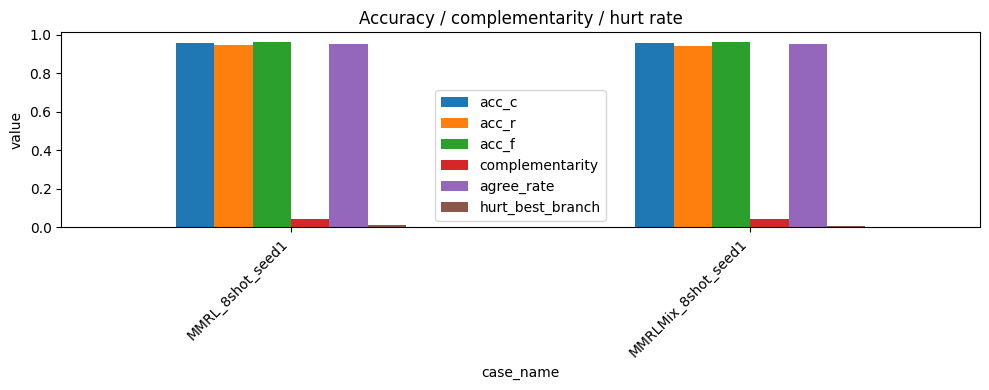

In [ ]:

plot_summary_bars(
    summary.set_index("case_name"),
    ["acc_c", "acc_r", "acc_f", "complementarity", "agree_rate", "hurt_best_branch"],
    title="Accuracy / complementarity / hurt rate"
)


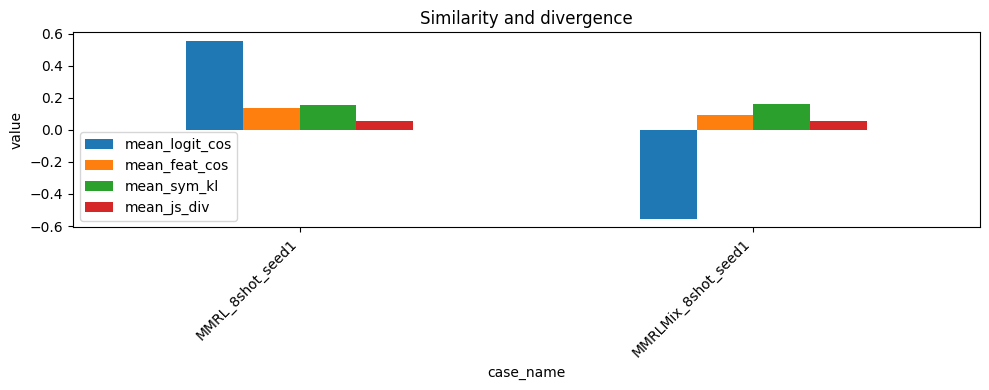

In [ ]:

plot_summary_bars(
    summary.set_index("case_name"),
    ["mean_logit_cos", "mean_feat_cos", "mean_sym_kl", "mean_js_div"],
    title="Similarity and divergence"
)


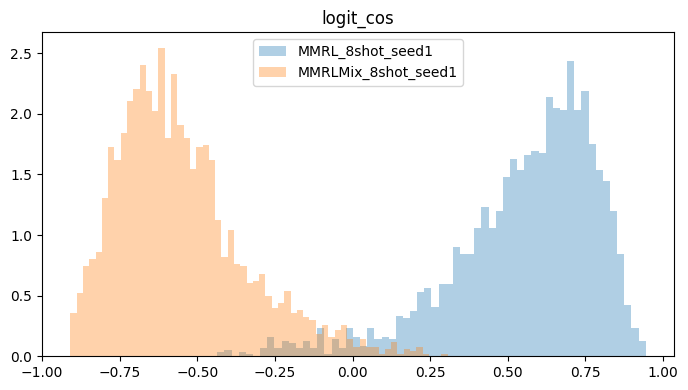

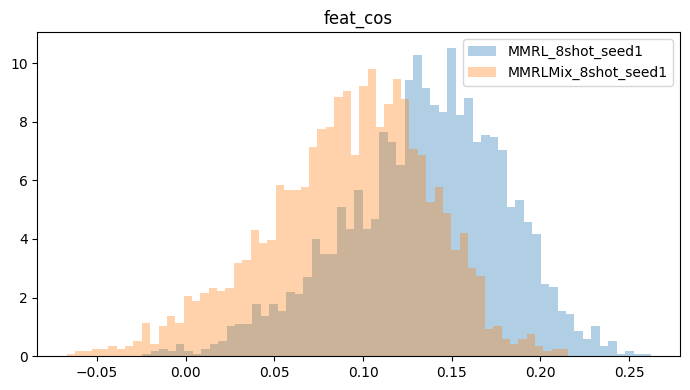

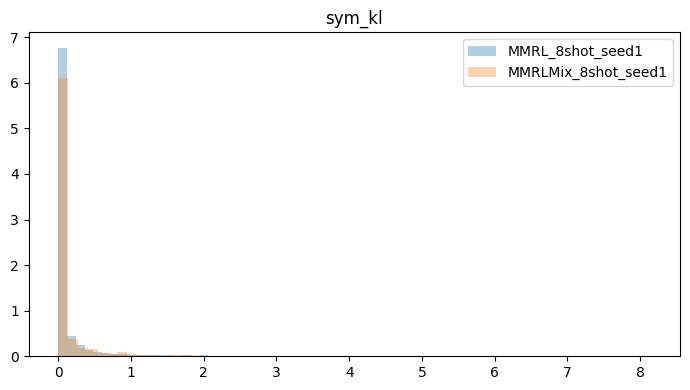

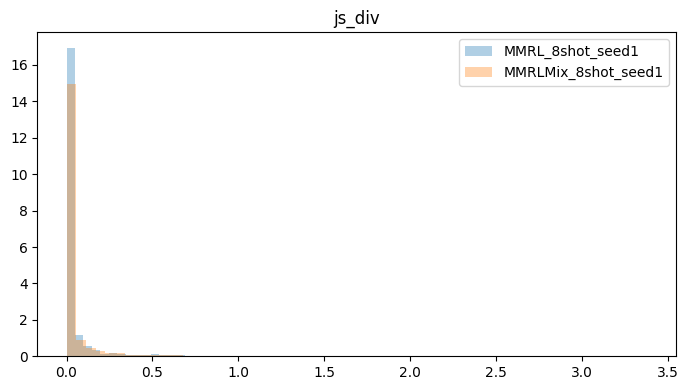

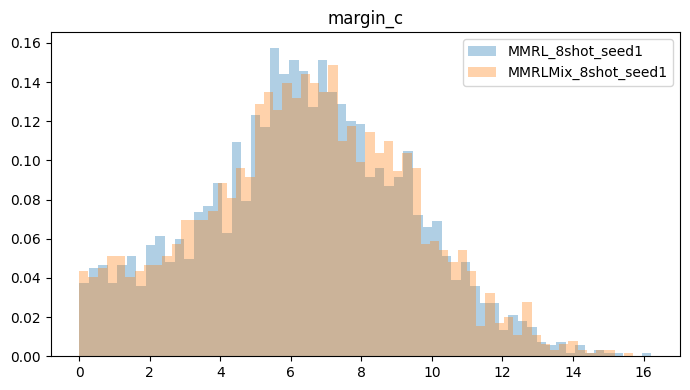

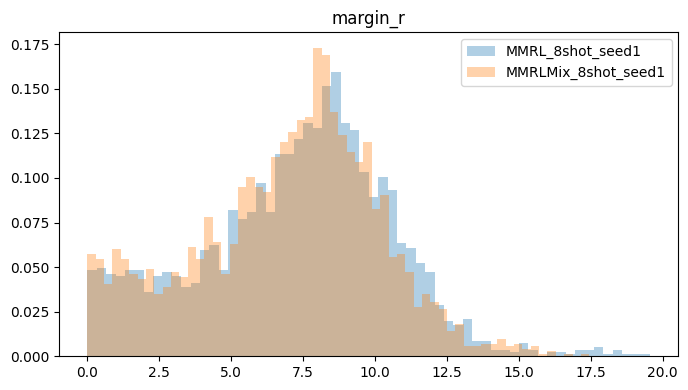

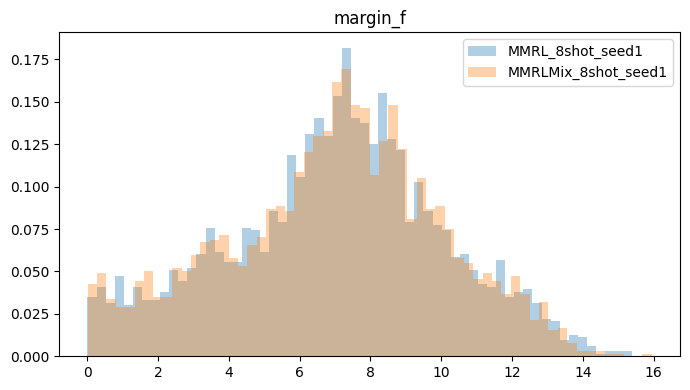

In [ ]:

for metric in ["logit_cos", "feat_cos", "sym_kl", "js_div", "margin_c", "margin_r", "margin_f"]:
    plot_case_distributions(df_all, metric)


In [ ]:

# 看 "fusion 把原本较优分支拉坏" 的具体样本比例
inspect_cols = [
    "case_name", "y",
    "pred_c", "pred_r", "pred_f",
    "correct_c", "correct_r", "correct_f",
    "agree_argmax",
    "logit_cos", "feat_cos", "sym_kl", "js_div",
    "margin_c", "margin_r", "margin_f",
    "conf_c", "conf_r", "conf_f",
    "hurt_best_branch",
]
df_all.loc[df_all["hurt_best_branch"] == 1, inspect_cols].head(20)


,case_name,y,pred_c,pred_r,pred_f,correct_c,correct_r,correct_f,agree_argmax,logit_cos,feat_cos,sym_kl,js_div,margin_c,margin_r,margin_f,conf_c,conf_r,conf_f,hurt_best_branch
917,MMRL_8shot_seed1,17,51,17,95,0,1,0,0,0.682673,0.154684,2.584953,0.887354,1.372051,0.449378,0.062222,0.720491,0.410628,0.376698,1
996,MMRL_8shot_seed1,21,97,21,97,0,1,0,0,0.649975,0.115743,0.703428,0.191472,2.151239,0.526400,1.347950,0.895527,0.627813,0.793475,1
1006,MMRL_8shot_seed1,21,97,21,97,0,1,0,0,0.644868,0.138544,1.283913,0.367518,1.124249,2.614208,0.002712,0.754748,0.931188,0.500626,1
1099,MMRL_8shot_seed1,26,58,26,58,0,1,0,0,0.751625,0.157299,0.311662,0.082588,1.486423,0.166449,0.990561,0.808426,0.541076,0.726920,1
1106,MMRL_8shot_seed1,26,58,26,58,0,1,0,0,0.842471,0.126183,1.197854,0.389120,1.148985,0.976215,0.444239,0.715298,0.482129,0.547249,1
1109,MMRL_8shot_seed1,26,58,26,58,0,1,0,0,0.672586,0.142914,0.340064,0.088882,1.665461,0.123117,1.128887,0.828991,0.528634,0.748434,1
1133,MMRL_8shot_seed1,27,27,26,26,1,0,0,0,0.648571,0.130718,0.835789,0.247237,0.460779,0.508043,0.080336,0.484876,0.502980,0.422313,1
1145,MMRL_8shot_seed1,28,27,28,27,0,1,0,0,0.812773,0.189707,1.375541,0.394501,1.293852,2.555655,0.139002,0.783816,0.927942,0.534511,1
1220,MMRL_8shot_seed1,32,32,8,8,1,0,0,0,0.768224,0.095725,1.387346,0.472048,0.270937,2.943720,0.693460,0.467802,0.943064,0.637754,1
1384,MMRL_8shot_seed1,40,41,40,41,0,1,0,0,0.797316,0.204109,0.760272,0.202823,1.387222,1.247095,0.596928,0.799898,0.776653,0.644794,1


In [ ]:

# 看 fusion 真正优于两条分支的样本
df_all.loc[df_all["fusion_beats_both"] == 1, inspect_cols].head(20)


,case_name,y,pred_c,pred_r,pred_f,correct_c,correct_r,correct_f,agree_argmax,logit_cos,feat_cos,sym_kl,js_div,margin_c,margin_r,margin_f,conf_c,conf_r,conf_f,hurt_best_branch
3162,MMRLMix_8shot_seed1,5,67,41,5,0,0,1,0,-0.566678,0.030027,3.343457,1.297348,0.501564,0.896634,0.084896,0.208183,0.500481,0.26647,0



## 推荐判断准则

如果你比较的是 **baseline MMRL** vs **加入 fusion CE 的版本**，并且你看到：

- `mean_logit_cos` / `mean_feat_cos` 更高
- `sym_kl` / `js_div` 更低
- `complementarity` 更低
- `hurt_best_branch` 更高
- `fusion_beats_both` 没有同步变高

那么就很支持下面这个判断：

> fusion CE 没有让两条分支学会更好的互补融合，反而把它们往更相似的方向拉了。

反过来，如果这些现象并不存在，就不能把问题归因于“拉齐分支”。


In [ ]:

# 可选：保存分析结果
SAVE_DIR = Path("./analysis_outputs")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

df_all.to_csv(SAVE_DIR / "per_sample_branch_analysis.csv", index=False)
summary.to_csv(SAVE_DIR / "summary_branch_analysis.csv", index=False)

print("Saved:")
print(SAVE_DIR / "per_sample_branch_analysis.csv")
print(SAVE_DIR / "summary_branch_analysis.csv")


Saved:
analysis_outputs/per_sample_branch_analysis.csv
analysis_outputs/summary_branch_analysis.csv
